# Peace and War genetic Algorithm
this is a personal project

<br/>

## pengenalan
ketika 2 individu ~soon atau lebih~ dengan resource mereka berevolusi agar bisa survive dengan 4 strategi aksi yaitu
* war
* peace
* grow
* move

apakah mendominasi atau bekerjasama atau saling apatis atau strategi lainnya yang dapat membuat mereka survive? mari kita simulasikan dengan algoritma genetika.

<br/>

---

## metodologi
### peta
dibuat peta lingkungan default 2x1

<br/>

| 1  | 2  |
| -- | -- |
| x  | x  |

<br/><br/>

### individu

dibuat 2 ~soon atau lebih~ individu (class) dengan attribute
* resource //value kekuatan individu
* intensity = 5 //jumlah intensitas kekuatan yang dikerahkan, default 0.
05
* position // posisi individu tersebut

### action
dibuat pula dengan 4 functions berikut
* war(individu opp)
* peace(individu opp)
* grow(individu opp)
* move(individu opp)

function war, trade, peace hanya bisa dilakukan saat satu lokasi dengan opponent, jika tidak dalam satu lokasi tidak terjadi apa-apa hanya mendapatkan score tetap. berikut

| action | self total add      | opp total add        | requirement |
| -------| ------------------- | -------------------- | ----------- |
| war    | +(opp\*a%+self\*a%) | -(opp\*a%+self\*2a%) | same spot   |
| peace  | -(self\*a%)         | +(self*a%)           | same spot   |
| grow   | +(self\*a%)         | +(opp\*0%)           | none        |
| move   | +(self\*0%)         | -(opp\*0%)           | none        |


<br/>

### treatment berbeda pada opponent kuat dan lemah

4 functions tadi dikombinasikan satu sama lain untuk menjadi fungsi yang memetakan perilaku terhadap opponent yang lebih kuat atau lebih lemah,

> actions[][] = action*action

| weaker\\stronger | war | peace | grow | move |
| ---------------- | --- | ----- | ---- | ---- |
| war              | 0,0 |  0,1  | 0,2  |  0,3 |
| peace            | 1,0 |  1,1  | 1,2  |  1,3 |
| grow             | 2,0 |  2,1  | 2,2  |  2,3 |
| move             | 3,0 |  3,1  | 3,2  |  3,3 |

> huruf representatif

| weaker\\stronger | war | peace | grow | move |
| ---------------- | --- | ----- | ---- | ---- |
| war              | *a* |  *b*  | *c*  |  *d* |
| peace            | *e* |  *f*  | *g*  |  *h* |
| grow             | *i* |  *j*  | *k*  |  *l* |
| move             | *m* |  *n*  | *o*  |  *p* |

contoh allel *h* merepresentasikan actions[1][3] adalah (peace,move), jika opponent dianggap lemah maka pelaku akan memilih act_stonger "peace" dan jika opponent dianggap kuat akan memilih act_weaker "move"  
<br/>

### Menetukan resource_ratio terhadap opponent
<br/>
\begin{align}
        \text{resource_ratio} = \left\{
        \begin{array}{cl}
        \frac{S_{\text{self}}}{S_{\text{opp}}} & S_{\text{self}} \le S_{\text{opp}} \\
        1 - \frac{S_{\text{opp}}}{S_{\text{self}}} & S_{\text{self}} > S_{\text{opp}}
        \end{array}
        \right.
    \end{align}
<br/>
contoh   

```
resource_self = 1
resource_opp = 5
resource_ratio1 = resource_self/resource_opp
resource_ratio1 -> 1/5

self = 5; opp = 1
resource_ratio2 = 1 - (resource_opp/resource_self)
resource_ratio2 -> 4/5
```
<br/>

### Menetukan action terhadap resource_ratio terhadap self_tact
<br/>
\begin{align}
        \text{action} = \left\{
        \begin{array}{cl}
        act\_weaker & resource\_ratio \le tact_{\text{self}} \\
        act\_stronger & resource\_ratio > tact_{\text{self}}
        \end{array}
        \right.
    \end{align}
<br/>
contoh menggunakan value resource ratio sebelumnya

```
resource_ratio1 -> 1/5
resource_ratio2 -> 4/5

tact_self = 0.4
allel = h
act_weaker = h[0]
act_weaker -> 'peace'
act_stronger = h[1]
act_stronger -> 'move'

if(resource_ratio < tact):
  self.peace(opp)
else:
  self.move(opp)

//resource_ratio1 < tact then: act_weaker
//resource_ratio2 >= tact then: act_stronger
```

<br/>

### Strategi
set strategi individu untuk dapat survive yaitu
* initiation
* reaction
* follow up reaction

#### initiation
individu dapat memilih fungsi a sampai p untuk action pertama ketika bertemu dengan opponent. Misal value *initiation* h, maka akan melakukan action peace (bebagi a% resource) ketika lawan dianggap lemah atau action move (berpindah posisi) ketika lawan dianggap kuat.
#### reaction
individu dapat memilih fungsi a sampai p untuk reaction dari *initiation* opponent. Misal opponent melakukan inisiasi war sedangkan value *reaction* self adalah *d*, maka ketika lawan dianggap lemah akan melakukan action war yaitu merebut resource sebesar (a%opp+a%self) dan ketika lawan dianggap kuat akan melakukan action move (berpindah posisi).
#### follow up reaction
individu dapat memilih fungsi a sampai p sebagai followup reaction sebagai lanjutan dari *initiation* opp dan *reaction* opp sebelumny. contoh apabila initiation opp adalah war dan opp memberikan reaction war lagi maka akan dibalas dari value *follow up reaction* self. *Follow up reaction* berbeda berdasarkan reaction opp sebelumnya sebagai berikut

| followup of war  |       |       |      |
| ---------------- | ----- | ----- | ---- |
| war              | peace | grow  | move |
| a~p              | a~p   | a~p   | a~p  |

| followup of peace|       |       |      |
| ---------------- | ----- | ----- | ---- |
| war              | peace | grow  | move |
| a~p              | a~p   | a~p   | a~p  |

| followup of grow |       |       |      |
| ---------------- | ----- | ----- | ---- |
| war              | peace | grow  | move |
| a~p              | a~p   | a~p   | a~p  |

| followup of move |       |       |      |
| ---------------- | ----- | ----- | ---- |
| war              | peace | grow  | move |
| a~p              | a~p   | a~p   | a~p  |

dilanjutkan dengan reaction untuk iterasi, jika sebelumnya saling beda posisi akan dimulai dari initiation lagi

<br/><br/>

---

### Encoding Kromosom
kromosom dibagi menjadi 4 segment dengan total 22 gen
* tact (float 0~1)
* initiation (functions[][] a~p)
* reaction 4*(functions[][] a~p)
* follow up reactions 4\*4*(functions[][] a~p)

kromosom backup akan aktif ketika gen sebelumnya tidak aktif, sebanyak 21
dengan ekspresi 'k','l','o','p' saja

# Game
membuat objek map dan individual serta peraturan gamenya
let's call it land and conqueror


## Setup


In [70]:
from collections import Counter
import re
import random
import matplotlib.pyplot as plt
import copy
import numpy as np

### Land

In [71]:
class Land:
  """
  A map for the simulation.

  Params
  ------
  x : int
      The width of the map (number of columns).
  y : int
      The height of the map (number of rows).

  Returns
  ------
  None
  """

  def __init__(self, x=10, y=10):
    self.x = x  # Width of the land (columns)
    self.y = y  # Height of the land (rows)
    self.grid = [['.' for _ in range(x)] for _ in range(y)]  # Map representation (initially empty)

  def reset_grid(self):
    """Resets the grid to an empty state."""
    self.grid = [['.' for _ in range(self.x)] for _ in range(self.y)]

  def update_position(self, conquerors):
    """
    Updates the position of the conquerors on the map.

    Parameters
    ----------
    conquerors : list of Conqueror
      List of conquerors to place on the map.

    Returns
    -------
    None
    """
    self.reset_grid()  # Clear the map

    for idx, conqueror in enumerate(conquerors):
      x, y = conqueror.position
      self.grid[y][x] = str(idx + 1)  # Place conqueror by index (1, 2, ...)

  def display_map(self):
    """Prints out the current state of the map with conquerors' positions."""
    for row in self.grid:
      print(' '.join(row))
  

### Game

In [72]:
# Randomized turn order function
def turn_order_game(A, B, turns = 10, mutation_rate=0, damage=0):
    random.seed(A.tact * B.tact * 10000)
    if random.choice([True, False]):
        A,B = A.actions(opp=B, stage=0, mutation_rate=mutation_rate )
        B,A = B.actions(opp=A, stage=0, mutation_rate=mutation_rate)
    else:
        B,A = B.actions(opp=A, stage=0, mutation_rate=mutation_rate)
        A,B = A.actions(opp=B, stage=0, mutation_rate=mutation_rate)
    A.resource -= damage
    B.resource -= damage

    for n in range(turns):
        A.resource -= damage
        B.resource -= damage

        for i in range(1,2) :
            random.seed(A.resource + B.resource)
            if random.choice([True, False]):
                A,B = A.actions(opp=B, stage=i, mutation_rate=mutation_rate)
                B,A = B.actions(opp=A, stage=i, mutation_rate=mutation_rate)
            else:
                B,A = B.actions(opp=A, stage=i, mutation_rate=mutation_rate)
                A,B = A.actions(opp=B, stage=i, mutation_rate=mutation_rate)
                
    return A,B

def war(self, opp):
    """Steals resources from the opponent, increases self resources by a percentage.

    Parameters
    ----------
    opp : Conqueror
        The opponent to battle.

    Returns
    -------
    self, opp : Conqueror
        Updated conqueror and opponent resources after war.
    """

    k = 1
    random.seed(self.resource+self.resource)
    if random.choice([True, False]):
      k = -0.5

    if opp.resource > 0:
      self.resource += (self.resource * self.intensity + opp.resource * self.intensity)*k
      opp.resource -= (self.resource * self.intensity + opp.resource * self.intensity * 2 - 2)
      
    return self, opp

def peace(self, opp):
    """Shares resources with the opponent.

    Parameters
    ----------
    opp : Conqueror
        The opponent to make peace with.

    Returns
    -------
    self, opp : Conqueror
        Updated resources after peace.
    """
    self.resource -= (self.resource * self.intensity)
    opp.resource += (self.resource * self.intensity + 2)
    return self, opp

def grow(self,opp):
    """Increases self resources by a percentage.

    Returns
    -------
    self : Conqueror
        Updated resource after growing.
    """
    k = 1
    random.seed(self.resource+self.resource)
    if random.choice([True, False]):
      k = -0.5

    self.resource += (self.resource * self.intensity)*k + 2
    return self, opp

def move(self, opp, land=Land()):
    """Moves the Conqueror on the map.

    Parameters
    ----------
    opp : Conqueror
        The opponent to consider when moving.
    land : Land
        The map where the conqueror moves.

    Returns
    -------
    self : Conqueror
        Updated position after moving.
    """
    # Get current position and bounds of the land
    x = self.position[0]
    y = self.position[1]
    max_x, max_y = land.x - 1, land.y - 1

    # If conqueror and opponent are in the same position, move them apart
    if self.position == opp.position:
        new_x = (x + 1) % (max_x + 1)  # Move to the next x-coordinate
        new_y = (y + 1) % (max_y + 1)  # Move to the next y-coordinate if needed
        self.position = [new_x, new_y]
    else:
        # Simple random move (can be improved with logic for directions, terrain, etc.)
        new_x = (x + 1) % (max_x + 1)  # Cycle within bounds of map
        new_y = y  # Or implement more complex movement logic
        self.position = [new_x, new_y]

    self.resource -= (self.resource * self.intensity)
    return self, opp


In [73]:
def population_game(conquerors, turns=10, mutation_rate=0, damage=0):
    # Loop through the turns
    for _ in range(turns):
        # For every pair of conquerors in the population
        for i in range(len(conquerors)):
            for j in range(i+1, len(conquerors)):  # Ensure each pair is only processed once
                A = conquerors[i]
                B = conquerors[j]

                # Deduct damage before actions
                A.resource -= damage
                B.resource -= damage

                # Handle the three stages: initiation, reaction, and follow-up reaction
                for stage in range(3):  # 0: initiation, 1: reaction, 2: follow-reaction
                    # Randomize turn order fairly for the pair
                    if random.choice([True, False]):
                        A, B = A.actions(opp=B, stage=stage, mutation_rate=mutation_rate)
                        B, A = B.actions(opp=A, stage=stage, mutation_rate=mutation_rate)
                    else:
                        B, A = B.actions(opp=A, stage=stage, mutation_rate=mutation_rate)
                        A, B = A.actions(opp=B, stage=stage, mutation_rate=mutation_rate)
                
                # Deduct additional damage after all stages if necessary
                A.resource -= damage
                B.resource -= damage

    return conquerors


### Conqueror

In [74]:
class Conqueror:
  """
  Represents an individual conqueror in the game.

  Params
  ------
  position: array[int,int]
      The x, y coordinates on the map.
  resource: int
      Resource the conqueror holds.
  tact: float
      Tactic value affecting decisions.
  intensity: float
      Percentage of resources used in actions.
  initiation: char
      Initial action to take.
  reaction: array[char]
      Reactions to different actions (5 elements).
  follow_reaction: array[char]
      Follow-up reactions to specific actions (5x5 grid).

  Returns
  ------
  None
  """

  def __init__(self, resource=100, intensity=0.05, tact=0.5, initiation="a", reaction=["a","f","k","p"],
               follow_reaction=[["a","f","k","p"],["a","f","k","p"],["a","f","k","p"],["a","f","k","p"]],
               position=[0, 0]):
    self.position = position  # Coordinates [x, y]
    self.resource = resource  # Resource points
    self.intensity = intensity  # Action intensity
    self.tact = tact  # Tactic value
    self.initiation = initiation  # Initial action type
    self.reaction = reaction  # Reaction to actions
    self.follow_reaction = follow_reaction  # Follow-up reactions
    self.opp_history = {}  # Record actions based on opponent's chromosome
    self.act_history = {}

  def get_strength_ratio(self,opp):
    if self.resource <= opp.resource:
      return self.resource / opp.resource
    else:
      return 1 - (opp.resource / self.resource)

  def get_chromosome(self):
    """Get the chromosome-like stats of the Conqueror in a formatted and colored way.

    Returns
    -------
    chromosome: string
    """
    # Convert tact to an integer percentage (multiplied by 100)
    tact_str = f"{int(self.tact * 100)}"

    # Convert reaction and follow-up reaction lists to strings
    reaction_str = ''.join(self.reaction)
    follow_reaction_str = ''.join([r for follow in self.follow_reaction for r in follow])

    tact_color = '\033[93m'  # Yellow
    initiation_color = '\033[92m'  # green
    reaction_color = '\033[34m'  # Blue
    reset_color = '\033[0m'  # Reset to default

    # Define a set of slightly different colors
    colors = [
        '\033[35;1m',  # Bright Magenta
        '\033[32;1m',  # Bright Green
        '\033[36;1m',  # Bright Cyan
        '\033[34;1m',  # Bright Blue
    ]

    # Prepare the colored follow_reaction_str
    colored_follow_reaction_str = ""
    for i in range(0, len(follow_reaction_str), 4):
        chunk = follow_reaction_str[i:i+4]  # Get 4 characters
        color = colors[(i // 4) % len(colors)]  # Select color based on chunk index
        colored_follow_reaction_str += f"{color}{chunk}{reset_color}"  # Add colored chunk

    # Concatenate the colored chromosome
    chromosome = (
        f"{tact_color}{tact_str}{reset_color}"
        f"{initiation_color}{self.initiation}{reset_color}"
        f"{reaction_color}{reaction_str}{reset_color}"
        f"{colored_follow_reaction_str}"
    )

    return chromosome

  def clean_chromosome(self, chromosome):
    ansi_escape = re.compile(r'\x1B\[[0-?]*[ -/]*[@-~]')
    return ansi_escape.sub('', chromosome)

  def decode(self, action_char):
    """Decodes a single action character ('a'~'p') into a (weaker, stronger) tuple.

    Params
    ------
    action_char: str
        A single character representing an action ('a'~'p').

    Returns
    -------
    tuple[int, int]
        A tuple representing the (weaker, stronger) position in the action table.
    """
    # Mapping characters to their corresponding (weaker, stronger) positions
    action_map = {
        'a': (0, 0), 'b': (0, 1), 'c': (0, 2), 'd': (0, 3),
        'e': (1, 0), 'f': (1, 1), 'g': (1, 2), 'h': (1, 3),
        'i': (2, 0), 'j': (2, 1), 'k': (2, 2), 'l': (2, 3),
        'm': (3, 0), 'n': (3, 1), 'o': (3, 2), 'p': (3, 3)
    }
    

    # Check if the character is valid and return its corresponding tuple
    if action_char in action_map:
        return action_map[action_char]
    else:
        raise ValueError(f"Invalid action character: {action_char}")

  # stages are 0 = initiation; 1 reaction; 2 = followup_reaction
  def actions(self, opp, land=Land(), stage = 0, mutation_rate = 0):
    self_chromosome = self.clean_chromosome(self.get_chromosome()) # Use self's chromosome as the identifier
    opp_chromosome = opp.clean_chromosome(opp.get_chromosome())    # Use opponent's chromosome as the identifier
    act = 0

    if self.tact >= self.get_strength_ratio(opp):
      act = 0
    else:
      act = 1

    if stage == 0 and (opp_chromosome in self.opp_history):
      stage = 1

    if stage == 0:
      decoded_action = self.decode(self.initiation)
    elif stage == 1:
      decoded_action = self.decode(self.reaction[self.opp_history[opp_chromosome][-1]])
    elif stage == 2:
      #mengecek yang pertama yang opp lakukan sebelumnya, gen akan meresponnya berdasarkan ratio kekuatan musuh
      decoded_action = self.decode(self.follow_reaction[self.opp_history[opp_chromosome][-1]]
                                   [self.opp_history[opp_chromosome][-2]])

    # Get the specific action based on the 'act' value (weaker/stronger)
    action_to_execute = decoded_action[act]

    # Get randomized action
    if mutation_rate > 0 :
      random.seed(self.tact)
      if random.random() < mutation_rate:
        action_to_execute = random.randint(0,99)%4

    if opp_chromosome not in self.opp_history:
      self.act_history[opp_chromosome] = []
      self.opp_history[opp_chromosome] = []
    if self_chromosome not in opp.opp_history:
      opp.act_history[self_chromosome] = []
      opp.opp_history[self_chromosome] = []
    
    
    self.act_history[opp_chromosome].append(action_to_execute)
    opp.opp_history[self_chromosome].append(action_to_execute)

    if ((self.position != opp.position and (action_to_execute == 0 or action_to_execute == 1  ))
        or (self.resource <= 0 or opp.resource <= 0)):      
      return self, opp
    else:
      if action_to_execute == 0:
        return war(self,opp)
      elif action_to_execute == 1:
        return peace(self,opp)
      elif action_to_execute == 2:
        return grow(self,opp)
      elif action_to_execute == 3:
        return move(self,opp,land)

  def show_stats(self):
    """Displays the chromosome-like stats of the Conqueror in a formatted and colored way."""
    print("resource\t:", self.resource)
    print("position\t:", self.position)
    print("gen\t\t:",self.get_chromosome())



In [75]:
A = Conqueror()
B = Conqueror()
conquerors = [A,B]
land = Land()

In [76]:
A,B = A.actions(B)

In [77]:
A.show_stats()
print(A.act_history)

resource	: 95.0
position	: [0, 0]
gen		: 50aafkpafkpafkpafkpafkp
{'50aafkpafkpafkpafkpafkp': [0]}


In [78]:
land.display_map()

. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .


In [79]:
land.update_position(conquerors)
land.display_map()

2 . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .


# Genetic Algorithm

## fitness function

In [80]:
def fitness(A):
    return A.resource

In [81]:
def fitness_domination(A,B):
    return A.resource - B.resource

In [82]:
def fitness_sum(A,B):
    return A.resource + B.resource

## populating

In [83]:
def populate_population(size=10):
    """
    Initialize the population with random Conqueror instances.
    
    Params:
    -------
    size: int
        The size of the population.
    
    Returns:
    --------
    list[Conqueror]
        A list of randomly initialized Conqueror instances.
    """
    population = []
    for _ in range(size):
        # Randomly generate attributes for each Conqueror
        # resource = random.randint(50, 150)  # random initial resources
        # intensity = random.uniform(0.01, 0.1)  # random intensity between 0.01 and 0.1
        tact = random.uniform(0.01, 0.99)  # random tact between 0.01 and 0.99
        initiation = random.choice("abcdefghijklmnop")  # random initiation action
        reaction = [random.choice("abcdefghijklmnop") for _ in range(4)]  # random reaction actions
        follow_reaction = [[random.choice("abcdefghijklmnop") for _ in range(4)] for _ in range(4)]  # random follow-up actions
        
        # Create a new Conqueror and add it to the population
        conqueror = Conqueror(tact = tact, initiation=initiation, reaction=reaction, follow_reaction=follow_reaction)
        population.append(conqueror)
    
    return population


In [84]:
def populate_red(size=10):
    """
    Initialize the population with random Conqueror instances.
    
    Params:
    -------
    size: int
        The size of the population.
    
    Returns:
    --------
    list[Conqueror]
        A list of randomly initialized Conqueror instances.
    """
    population = []
    for _ in range(size):
        # Randomly generate attributes for each Conqueror
        # resource = random.randint(50, 150)  # random initial resources
        # intensity = random.uniform(0.01, 0.1)  # random intensity between 0.01 and 0.1
        tact = random.uniform(0.01, 0.99)  # random tact between 0.01 and 0.99
        initiation = random.choice("abcdefghijklmnop")  # random initiation action
        reaction = [random.choice("abcdefghijklmnop") for _ in range(4)]  # random reaction actions
        follow_reaction = [[random.choice("abcdefghijklmnop") for _ in range(4)] for _ in range(4)]  # random follow-up actions
        
        # Create a new Conqueror and add it to the population
        conqueror = Conqueror(tact = tact, initiation=initiation, reaction=reaction, follow_reaction=follow_reaction)
        population.append(conqueror)
    
    return population

## selection

In [85]:
def select_parents(population):
    """
    Select two parents from the population using Stochastic Universal Sampling (SUS).
    
    Params:
    -------
    population: list[Conqueror]
    
    Returns:
    --------
    Conqueror, Conqueror
        Two selected parents for crossover.
    """
    total_fitness = sum(conq.resource for conq in population)
    
    # Calculate the fitness proportion for each Conqueror
    selection_probs = [conq.resource / total_fitness for conq in population]
    
    # Calculate cumulative probabilities for the population
    cumulative_probs = []
    cumulative_sum = 0
    for prob in selection_probs:
        cumulative_sum += prob
        cumulative_probs.append(cumulative_sum)
    
    # Generate a random starting point and define a step size
    start_point = random.uniform(0, 1 / 2)
    step_size = 1 / 2
    
    # Use the baker's wheel approach to select two unique parents
    parents = []
    for i in range(2):
        pointer = start_point + i * step_size
        
        # Select the parent by finding where the pointer lands
        for idx, cum_prob in enumerate(cumulative_probs):
            if pointer <= cum_prob:
                parents.append(population[idx])
                break
    
    parent1, parent2 = parents
    return parent1, parent2


## crossover

In [86]:
def crossover(parent1, parent2):
    """
    Perform crossover between two Conquerors to produce an offspring.
    
    Params:
    -------
    parent1: Conqueror
    parent2: Conqueror
    
    Returns:
    --------
    Conqueror
        The offspring generated from the two parents.
    """
    # Example crossover logic (simple blend of attributes)
    # resource = (parent1.resource + parent2.resource) // 2
    # intensity = (parent1.intensity + parent2.intensity) / 2
    tact = (parent1.tact + parent2.tact) / 2.0
    
    # Combine initiation and reactions randomly
    initiation = random.choice([parent1.initiation, parent2.initiation])
    reaction = [random.choice([r1, r2]) for r1, r2 in zip(parent1.reaction, parent2.reaction)]
    follow_reaction = [
        [random.choice([fr1, fr2]) for fr1, fr2 in zip(follow1, follow2)]
        for follow1, follow2 in zip(parent1.follow_reaction, parent2.follow_reaction)
    ]
    
    return Conqueror(tact=tact, initiation=initiation, reaction=reaction, follow_reaction=follow_reaction)


## mutation

In [87]:
# def mutate(conqueror, mutation_rate=0.1):
#     """
#     Mutate the given Conqueror with a certain probability.
    
#     Params:
#     -------
#     conqueror: Conqueror
#     mutation_rate: float
#         The probability of mutation.
    
#     Returns:
#     --------
#     Conqueror
#         The mutated Conqueror.
#     """
#     random.seed()
#     if random.random() < mutation_rate:
#         # Mutate resource, intensity, or tact
#         # conqueror.resource += random.randint(-10, 10)
#         # conqueror.intensity += random.uniform(-0.01, 0.01)
#         conqueror.tact += random.uniform(-0.05, 0.05)
        
#         # Mutate initiation or reactions
#         conqueror.initiation = random.choice("abcdefghijklmnop")
#         conqueror.reaction = [random.choice("abcdefghijklmnop") for _ in range(4)]
#         conqueror.follow_reaction = [[random.choice("abcdefghijklmnop") for _ in range(4)] for _ in range(4)]
    
#     return conqueror


In [88]:
action_map = {
        'a': (0, 0), 'b': (0, 1), 'c': (0, 2), 'd': (0, 3),
        'e': (1, 0), 'f': (1, 1), 'g': (1, 2), 'h': (1, 3),
        'i': (2, 0), 'j': (2, 1), 'k': (2, 2), 'l': (2, 3),
        'm': (3, 0), 'n': (3, 1), 'o': (3, 2), 'p': (3, 3)
    }
# Define reverse action map to get character from (row, col)
reverse_action_map = {v: k for k, v in action_map.items()}

# Helper function to shift a character within the same row or column
def shift_character(character):
    # Get the current position from the action map
    row_idx, col_idx = action_map[character]
    
    # Determine possible shifts (neighbors in the row and column)
    possible_shifts = []
    
    # Horizontal shifts (same row)
    for delta_col in [-1, 1]:
        new_col_idx = (col_idx + delta_col) % 4  # Wrap around horizontally
        possible_shifts.append((row_idx, new_col_idx))
    
    # Vertical shifts (same column)
    for delta_row in [-1, 1]:
        new_row_idx = (row_idx + delta_row) % 4  # Wrap around vertically
        possible_shifts.append((new_row_idx, col_idx))
    
    # Randomly choose one of the possible shifts
    new_position = random.choice(possible_shifts)
    
    # Return the character at the new position
    return reverse_action_map[new_position]

# Mutation function with shift-based mutation
def mutate(conqueror, mutation_rate=0.1):
    """
    Mutate the given Conqueror with a certain probability using shift-based mutation.
    
    Params:
    -------
    conqueror: Conqueror
    mutation_rate: float
        The probability of mutation.
    
    Returns:
    --------
    Conqueror
        The mutated Conqueror.
    """
    random.seed()
    if random.random() < mutation_rate:
        # Mutasi resource, intensity, or tact
        conqueror.tact += random.uniform(-0.05, 0.05)
        
        # mutasi initiation dengan shift-based mutation
        conqueror.initiation = shift_character(conqueror.initiation)
        
        # mutasi reaksi dengan shift-based mutation
        conqueror.reaction = [shift_character(c) for c in conqueror.reaction]
        
        # Mutate follow_reaction dengan shift-based mutation
        conqueror.follow_reaction = [[shift_character(c) for c in follow] for follow in conqueror.follow_reaction]
    
    return conqueror


## Compiled GA

In [89]:
def genetic_algorithm(generations=100, population_size=10, turns=3, land=Land(), mutation_rate=0.1):
    best_eachgen = []
    best_fitness = []
    avg_fitness = []

    population = populate_population(population_size)
    
    for generation in range(generations):
        for individual in population:
            individual.resource = 100
            individual.opp_history = {}
            individual.act_history = {}

        for i in range(int(population_size/2)):
            population[i],population[-i] = turn_order_game(population[i],population[-i],turns=turns, mutation_rate=mutation_rate)
        
        # Evaluate fitness of the population
        population = sorted(population, key=fitness, reverse=True)
        print(f"Generation {generation}: Best fitness = {(population[0].resource):.3f} \t|| {(population[0].get_chromosome())}")
        best_fitness.append(population[0].resource)
        best_eachgen.append(copy.deepcopy(population[0]))
        avg_fitness.append(sum(conq.resource for conq in population)/len(population))

        # Select the top half of the population to breed
        new_population = populate_population(int(population_size/5))
        for i in range(int(population_size/5)):
            new_population.append(population[i])

        while len(new_population) < population_size:
            parent1, parent2 = select_parents(population)
            offspring1 = crossover(parent1, parent2)
            offspring1 = mutate(offspring1, mutation_rate)
            new_population.append(offspring1)

        
        random.shuffle(new_population)
        population = new_population

    
    return best_eachgen, best_fitness, avg_fitness


In [90]:
def algogen(generations=20, population_size=100, turns=3, land=Land(), mutation_rate=0.1, progress = False):
    best_eachgen = []
    best_fitness = []
    avg_fitness = []

    population = populate_population(population_size)

    print("doing god's works ...")
    for generation in range(generations):
        # Reset resource for each individual in the population to 100
        for individual in population:
            individual.resource = 100
            individual.opp_history = {}
            individual.act_history = {}

        population = population_game(population)

        # Evaluate fitness of the population
        population = sorted(population, key=fitness, reverse=True)
        if progress : print(f"Generation {generation}: Best fitness = {(population[0].resource):.3f} \t|| {(population[0].get_chromosome())}")
        best_fitness.append(population[0].resource)
        best_eachgen.append(copy.deepcopy(population[0]))
        avg_fitness.append(sum(conq.resource for conq in population)/len(population))

        # Select the top half of the population to breed
        # new_population = populate_population(int(population_size/5))
        new_population = populate_population(0)
        # for i in range(int(population_size/5)):
        #     new_population.append(population[i])

        while len(new_population) < population_size:
            parent1, parent2 = select_parents(population)
            offspring1 = crossover(parent1, parent2)
            offspring1 = mutate(offspring1, mutation_rate)
            new_population.append(offspring1)
        
        random.shuffle(new_population)
        population = new_population

    print("God's works came to end ... time to evaluate!")
    
    return best_eachgen, best_fitness, avg_fitness


# Implementation

In [91]:
def plot_best_fit(generation_best_fits, average_fits):
    """
    Plots the best fit values and average fit values for each generation.

    Parameters
    ----------
    generation_best_fits : list[float]
        A list containing the best fit value for each generation.
    average_fits : list[float]
        A list containing the average fit value for each generation.
    
    Returns
    -------
    None
    """
    plt.figure(figsize=(10, 5))
    
    # Plot best fit and average fit
    plt.plot(generation_best_fits, marker='o', linestyle='-', color='b', label="Best Fit")
    plt.plot(average_fits, marker='o', linestyle='-', color='y', label="Average Fit")
    
    # Add title and axis labels
    plt.title('Best and Average Fit Values Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Value')
    
    # Set x-ticks to correspond to generations
    plt.xticks(range(len(generation_best_fits)))
    
    # Add grid
    plt.grid()

    # Add legend
    plt.legend()  # This will display the labels you specified earlier

    # Show plot
    plt.show()


In [92]:
def moving_average(data, window_size):
    """Apply a moving average to smooth the data."""
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

def plot_best_fit_smooth(generation_best_fits, average_fits, window_size=10):
    """
    Plots the best fit values and average fit values for each generation with smoothing.

    Parameters
    ----------
    generation_best_fits : list[float]
        A list containing the best fit value for each generation.
    average_fits : list[float]
        A list containing the average fit value for each generation.
    window_size : int, optional
        The window size for the moving average smoothing (default is 10).
    
    Returns
    -------
    None
    """
    # Apply moving average to smooth the data
    smoothed_best_fits = moving_average(generation_best_fits, window_size)
    smoothed_average_fits = moving_average(average_fits, window_size)
    
    # Generate x values for the smoothed data
    x_values = np.arange(window_size - 1, len(generation_best_fits))
    
    plt.figure(figsize=(10, 5))
    
    # Plot smoothed best fit and average fit
    plt.plot(x_values, smoothed_best_fits, marker='o', linestyle='-', color='b', label="Best Fit (Smoothed)")
    plt.plot(x_values, smoothed_average_fits, marker='o', linestyle='-', color='y', label="Average Fit (Smoothed)")
    
    # Add title and axis labels
    plt.title


In [ ]:
# top_eachgen, top_fitness, avg_fits = genetic_algorithm(generations=100, turns=24, population_size=10, mutation_rate=0.1)
top_eachgen, top_fitness, avg_fits = algogen(generations=100, turns=10, population_size=10, mutation_rate=0.1)

doing god's works ...


## Coba cek

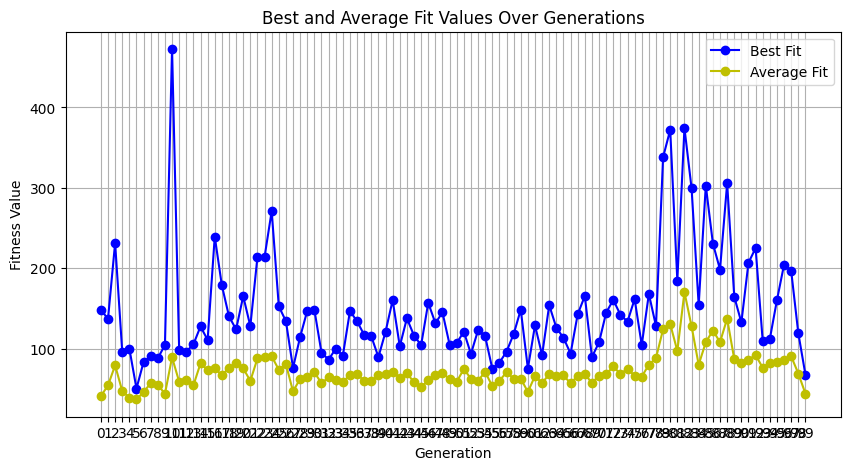

In [60]:
# plot_best_fit_smooth(top_fitness, avg_fits, window_size=10)
plot_best_fit(top_fitness, avg_fits)

## cek lain

In [61]:
def chromosome_with_differences(chromosome1, chromosome2):
    """
    Compare two chromosomes and return a new chromosome
    where matching elements remain the same, and differing
    elements are replaced with 'x'.

    Params:
    -------
    chromosome1: list or string
        The first chromosome (can be a list of elements or a string).
    chromosome2: list or string
        The second chromosome (can be a list of elements or a string).

    Returns:
    --------
    result: list or string
        The new chromosome with matching elements intact and differing elements as 'x'.
    """

    # Convert chromosome to a list if it's a string
    ansi_escape = re.compile(r'\x1B\[[0-?9;]*[mK]')  # Regex pattern to match ANSI escape sequences
    chromosome1 = ansi_escape.sub('', chromosome1)
    ansi_escape = re.compile(r'\x1B\[[0-?9;]*[mK]')  # Regex pattern to match ANSI escape sequences
    chromosome2 = ansi_escape.sub('', chromosome2)
    # Initialize an empty list to store the result
    result = []

    # Ensure both chromosomes are of the same length to compare
    min_length = min(len(chromosome1), len(chromosome2))

    # Loop through both chromosomes and check for matching elements
    for i in range(min_length):
        if chromosome1[i] == chromosome2[i]:
            result.append(chromosome1[i])  # Keep the matching element
        else:
            result.append('x')  # Replace with 'x' for differing elements

    # Return the result in the same format as the input
    return ''.join(result) if isinstance(chromosome1, str) else result


In [62]:
def count_allele_expressions(chromosome):
    """
    Count the expression of each allele in the chromosome.

    Params:
    -------
    chromosome: list or string
        The chromosome for which to count allele expressions.

    Returns:
    --------
    dict
        A dictionary with alleles as keys and their counts as values.
    """
    # Convert chromosome to a list if it's a string
    ansi_escape = re.compile(r'\x1B\[[0-?9;]*[mK]')  # Regex pattern to match ANSI escape sequences
    chromosome = ansi_escape.sub('', chromosome)

    if isinstance(chromosome, str):
        chromosome = list(chromosome)
    
    # Count the occurrences of each allele
    allele_count = Counter(chromosome)

    return dict(allele_count)  # Convert Counter to a regular dictionary for better readability


In [63]:
def actions_check(top_eachgen, gen = 0):
    print(top_eachgen[gen].get_chromosome())
    print(fitness(top_eachgen[gen]),"\n")
    for opp in top_eachgen[gen].opp_history:
        print(opp)
        print("self :",top_eachgen[gen].act_history[opp],"\nopp  :",top_eachgen[gen].opp_history[opp] )

In [64]:
sorted_gen = sorted(top_eachgen, key=fitness, reverse=True)

In [65]:
print(sorted_gen[0].get_chromosome())
allele_counts = count_allele_expressions(top_eachgen[0].get_chromosome())
print(allele_counts)  # Output: {'a': 2, 'b': 2, 'c': 2, 'd': 1, 'e': 1}

53mkkocgkkklebfjkjhgkci
{'4': 1, '6': 1, 'j': 4, 'g': 3, 'd': 2, 'k': 2, 'i': 2, 'l': 2, 'c': 2, 'a': 2, 'e': 1, 'o': 1}


In [66]:
# Example usage:
print(sorted_gen[0].get_chromosome())
allele_counts = count_allele_expressions(sorted_gen[0].get_chromosome())
print(allele_counts)  # Output: {'a': 2, 'b': 2, 'c': 2, 'd': 1, 'e': 1}

53mkkocgkkklebfjkjhgkci
{'5': 1, '3': 1, 'm': 1, 'k': 7, 'o': 1, 'c': 2, 'g': 2, 'l': 1, 'e': 1, 'b': 1, 'f': 1, 'j': 2, 'h': 1, 'i': 1}


In [67]:
print(chromosome_with_differences(sorted_gen[13].get_chromosome(), sorted_gen[2].get_chromosome())) 

5xxkxcxgikxxexxkxxxkxci


In [68]:
top_fitness[0]

148.47641196082242

##### cek action

In [69]:
actions_check(sorted_gen, gen=0) #since it's sorted gen is rank

53mkkocgkkklebfjkjhgkci
472.37146847592385 

53cjjphgplhliclgkfcogda
self : [3, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1] 
opp  : [2, 1, 0, 3, 3, 1, 3, 3, 2, 3, 3, 1, 2, 3, 1, 3, 3, 2, 3, 3, 1, 2, 3, 1, 2, 3, 1, 3, 3, 1]
54ckjohfpkkplblkljcojdi
self : [0, 2, 1, 3, 0, 2, 3, 3, 0, 2, 2, 2, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3] 
opp  : [2, 2, 2, 3, 3, 2, 2, 3, 2, 2, 3, 2, 3, 3, 2, 1, 3, 2, 1, 3, 2, 3, 3, 2, 3, 3, 2, 1, 3, 2]
53nlgphglldleclkkndognm
self : [2, 0, 2, 0, 3, 2, 3, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0] 
opp  : [1, 3, 2, 3, 2, 2, 1, 1, 0, 1, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 2]
54mkhocfkjdlecjgljhggni
self : [2, 3, 0, 0, 3, 1, 3, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 3, 2, 2, 2, 2, 2, 3] 
opp  : [0, 2, 3, 2, 2, 2, 0, 3, 3, 2, 2, 1, 3, 3, 2, 2, 3, 2, 3, 3, 2, 2, 3, 2, 0, 3, 2, 3, 3, 2]
53cjjphgplgkeblkkndogdm
self : [3, 0, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 